## **Analysis of the elevation change rate drived by dems.**
#### 1) Elevation change correction based on elevation changes on the stable region. 
#### ${dh}_{glacier-cor} = {dh}_{glacier} - {dh}_{stable}$
#### The time-series ${dh}_{glacier-cor}$ are then linear fitted by by ransac algorithm.
#### 2) Uncertainty estimation of elevation change rate. 
#### $\epsilon_{ransac} = y_i - y_{fitting}$
#### $\sigma_{dh} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\epsilon_{i} - \overline{\epsilon})^2} $
#### $\sigma_\frac{dh}{dt} = \frac{\sigma_{dh}}{dt}$
The n refer to the number of the years, and the i is the i-th year.

### comtent
1. Elevation change on the stable region (For elevation change correction and uncertainty estimation).
- 1.1 Elevation change on the overall setp stable region.
- 1.2 Elevation change on one tile.
2. Elevation change on the glacier region.
- 2.1. Elevation change on the overall setp region.
- 2.2 Elevation change of tiles.
- 2.3 Elevation changes of elevation bins.
3. Write out the result.


In [1]:
import os
import h5py
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils.ransac_fitting import ransac_fitting
from utils.tiles_bins_weighting import stat_tiles_weighting, stat_bins_tiles_weighting, stat_tiles_bins_weighting


In [2]:
paths_stat_dems = 'data/aster-stereo/stat_dif_tiles_sub_bins.nc'   ## path of statistics 
path_result_dems = 'data/ele-change-result/ele_change_dems_tiles_sub.nc'


In [3]:
stat_dif_dems_xr = xr.open_dataset(paths_stat_dems)
stat_dif_dems_xr
tiles_id = stat_dif_dems_xr.tiles_id.values
bins_id = stat_dif_dems_xr.bins_id.values
years = stat_dif_dems_xr.years.values
x_years = np.array([i for i in range(len(years))])
len(years)


23

### 1. Elevation change on the overall setp stable region.

Ransac coefficient for stable setp region: -0.015285961713025034


(-6.0, 6.0)

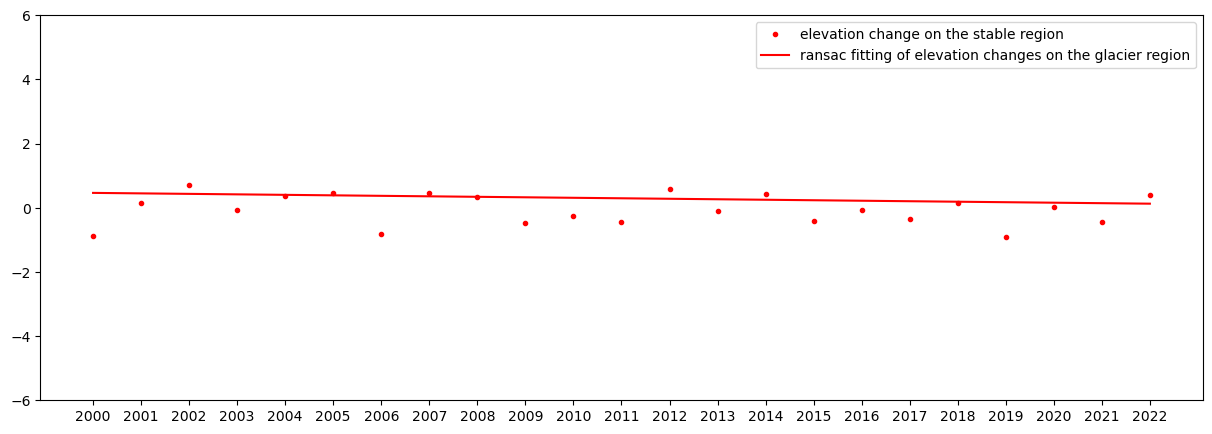

In [4]:
mean_setp_stable_tilesWeighted, std_setp_stable_tilesWeighted = stat_tiles_weighting(mean_tiles = stat_dif_dems_xr['mean_stable_tiles'], \
                                                                    std_tiles = stat_dif_dems_xr['std_stable_tiles'], 
                                                                    glacier_area_tiles = stat_dif_dems_xr['area_glacier_tiles'])
mean_setp_stable_filtered, mean_setp_stable_fitting, rate_setp_stable = ransac_fitting(x=x_years, y=mean_setp_stable_tilesWeighted.values, thre_mask=50)
print('Ransac coefficient for stable setp region:', rate_setp_stable)
plt.figure(figsize=(15, 5))
plt.plot(years, mean_setp_stable_tilesWeighted, '.r', label='elevation change on the stable region')
plt.plot(years, mean_setp_stable_fitting, '-r', label='ransac fitting of elevation changes on the glacier region')   ### bin-based area weighting -> tile-based area weighting
plt.legend()
plt.ylim(bottom=-6, top=6)



### 2. Elevation change on the glacier region.


#### 2.1 Elevation change on the overall setp region.

##### 2.1.1 Glacier area weighted elevation change on the glacier region.

In [5]:
### From bins weighting to tiles weighting.
mean_tiles_glacier_binsWeighted, std_tiles_glacier_binsWeighted, mean_setp_glacier_tilesWeighted, std_setp_glacier_tilesWeighted = \
                                stat_bins_tiles_weighting(mean_tiles_bins=stat_dif_dems_xr['mean_glacier_tiles_bins'], \
                                                    std_tiles_bins=stat_dif_dems_xr['std_glacier_tiles_bins'], 
                                                    glacier_area_tiles_bins=stat_dif_dems_xr['area_glacier_tiles_bins'])

### From tiles weighting to bins weighting.
mean_bins_glacier_tilesWeighted, std_bins_glacier_tilesWeighted, mean_setp_glacier_binsWeighted, std_setp_glacier_binsWeighted = \
                                            stat_tiles_bins_weighting(mean_tiles_bins=stat_dif_dems_xr['mean_glacier_tiles_bins'], \
                                                            std_tiles_bins=stat_dif_dems_xr['std_glacier_tiles_bins'], 
                                                            glacier_area_tiles_bins=stat_dif_dems_xr['area_glacier_tiles_bins'])



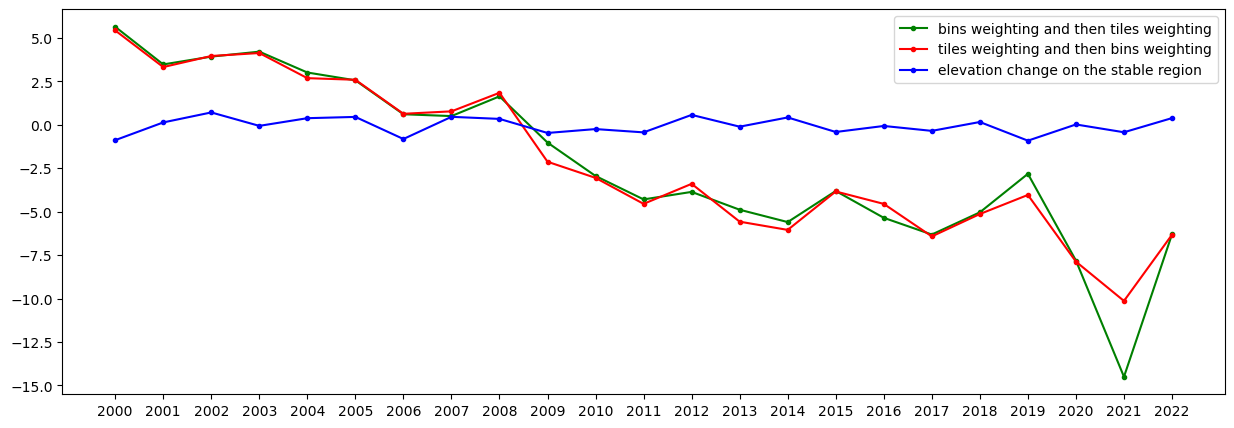

In [6]:
plt.figure(figsize=(15,5))
plt.plot(years, mean_setp_glacier_tilesWeighted, '.-g', label='bins weighting and then tiles weighting')   ### bin-based area weighting -> tile-based area weighting
plt.plot(years, mean_setp_glacier_binsWeighted, '.-r', label='tiles weighting and then bins weighting')   ### tile-based area weighting -> bin-based area weighting
plt.plot(years, mean_setp_stable_tilesWeighted, '.-b', label='elevation change on the stable region')
plt.legend()


##### 2.1.2 Elevation change correction with elevation change on the stable region
##### **!!!! Note: the elevation changes much from 2008 to 2009.** 

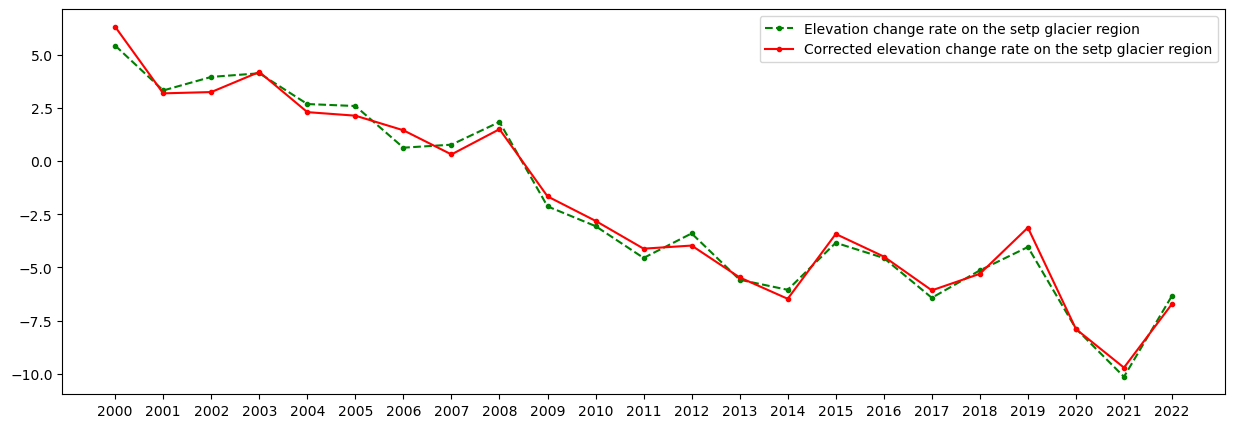

In [7]:
## New method.
### elevation change
mean_setp_glacier_cor = mean_setp_glacier_binsWeighted.values - mean_setp_stable_tilesWeighted.values
### standard deviation of elevation change.
std_setp_glacier_cor = np.sqrt(np.square(std_setp_stable_tilesWeighted.values) + np.square(std_setp_glacier_tilesWeighted.values)) 
# print('Corrected elevation change rate for the overall setp glacier region:', ransac_coef_setp_glacier_cor[0])
plt.figure(figsize=(15, 5))
plt.plot(years, mean_setp_glacier_binsWeighted.values, '.--g', label='Elevation change rate on the setp glacier region')
plt.plot(years, mean_setp_glacier_cor, '.-r', label='Corrected elevation change rate on the setp glacier region')
# plt.plot(years, mean_setp_glacier_cor_fitting, '-r', label='Linear fitting of corrected elevation change rate on the setp glacier region')
plt.legend()



##### 2.1.3 Elevation change rate estimation by ransac algorithm.

Elevation change rate: -0.6038050340668785
Elevation change rate (2000-2012): -0.9117618198495486
Elevation change rate (2012-2022): -0.9670891725565096


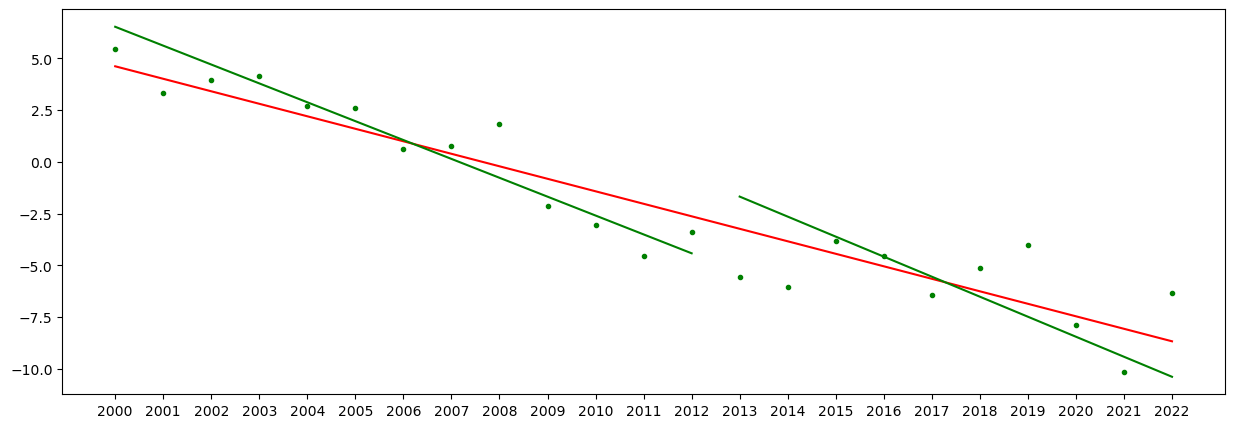

In [8]:
i_year_middle = 13
#### Time interval: 2000-2022
x_years = np.array([i for i in range(len(years))])
mean_setp_glacier_cor_filtered, mean_setp_glacier_cor_fitting, rate_setp_glacier_cor = ransac_fitting(x=x_years, \
                                                                y=mean_setp_glacier_cor, thre_mask=50)
print('Elevation change rate:', rate_setp_glacier_cor)

#### Time interval: 2000-2012
mean_setp_glacier_cor_2000_2012_filtered, mean_setp_glacier_cor_2000_2012_fitting, rate_setp_glacier_cor_2000_2012 = ransac_fitting(x=x_years[0:i_year_middle], \
                                                                y=mean_setp_glacier_cor[0:i_year_middle], thre_mask=50)
print('Elevation change rate (2000-2012):', rate_setp_glacier_cor_2000_2012)

#### Time interval: 2013-2022
mean_setp_glacier_cor_2013_2022_filtered, mean_setp_glacier_cor_2013_2022_fitting, rate_setp_glacier_cor_2013_2022 = ransac_fitting(x=x_years[i_year_middle:], \
                                                                y=mean_setp_glacier_cor[i_year_middle:], thre_mask=50)
print('Elevation change rate (2012-2022):', rate_setp_glacier_cor_2013_2022)

plt.figure(figsize=(15,5))
plt.plot(years, mean_setp_glacier_binsWeighted.values, '.g')
plt.plot(years, mean_setp_glacier_cor_fitting, '-r')
plt.plot(years[0:i_year_middle], mean_setp_glacier_cor_2000_2012_fitting, '-g')
plt.plot(years[i_year_middle:], mean_setp_glacier_cor_2013_2022_fitting, '-g')



##### 2.1.4 Elevation change rate uncertainty estimation.

In [9]:
#### 1. Time interval: 2000-2021
epsilon = mean_setp_glacier_cor - mean_setp_glacier_cor_fitting
sigma_dh = np.std(epsilon)
sigma_dh_dt = sigma_dh/len(years)
# print('sigma_dh:', sigma_dh)
print('sigma_dh_dt:', sigma_dh_dt)

#### 2. Time interval: 2000-2012
epsilon = mean_setp_glacier_cor[0:i_year_middle] - mean_setp_glacier_cor_2000_2012_fitting
sigma_dh_2000_2012 = np.std(epsilon)
sigma_dh_dt_2000_2012 = sigma_dh_2000_2012/mean_setp_glacier_cor[0:i_year_middle].shape[0]
# print('sigma_dh for 2000-2012:', sigma_dh)
print('sigma_dh_dt for 2000-2012:', sigma_dh_dt_2000_2012)

#### 3. Time interval: 2012-2021
epsilon = mean_setp_glacier_cor[i_year_middle:] - mean_setp_glacier_cor_2013_2022_fitting
sigma_dh_2013_2022 = np.std(epsilon)
sigma_dh_dt_2013_2022 = sigma_dh_2013_2022/mean_setp_glacier_cor[i_year_middle:].shape[0]
# print('sigma_dh for 2000-2012:', sigma_dh)
print('sigma_dh_dt for 2012-2022:', sigma_dh_dt_2013_2022)


sigma_dh_dt: 0.06587997027964682
sigma_dh_dt for 2000-2012: 0.0807640650977954
sigma_dh_dt for 2012-2022: 0.25172889571858065


#### 2.2 Elevation change of tiles.


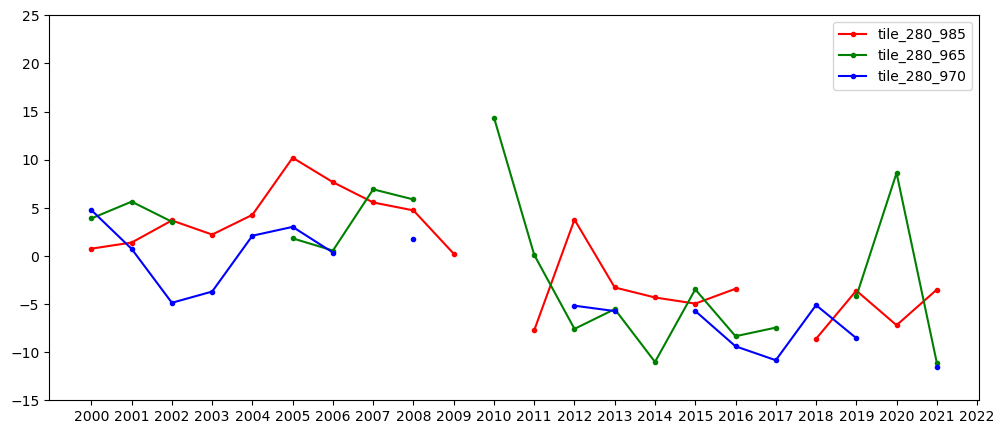

In [53]:
tile_id_1, tile_id_2, tile_id_3, tile_id_4 = tiles_id[21], tiles_id[17], tiles_id[18], tiles_id[23]
plt.figure(figsize=(12,5))
plt.plot(years, mean_tiles_glacier_binsWeighted.sel(tiles_id = tile_id_1).values, '.-r', label=tile_id_1)
plt.plot(years, mean_tiles_glacier_binsWeighted.sel(tiles_id = tile_id_2), '.-g', label=tile_id_2)
plt.plot(years, mean_tiles_glacier_binsWeighted.sel(tiles_id = tile_id_3), '.-b', label=tile_id_3)
plt.ylim(-15,25)
plt.legend()


#### 2.2.1 Tile-based elevation change rate estimation with corrected elevation change, and write out

In [56]:
# tile_id =  'tile_27_98'
tiles_id = mean_tiles_glacier_binsWeighted['tiles_id'].values
rate_tiles = []
rate_error_tiles = []
glacier_area_tiles = {}
mean_glacier_cor_tiles = []
for tile_id in tiles_id:
  # tile_id =  'tile_27_98'  
  # print(tile_id)
  mean_glacier_tile = mean_tiles_glacier_binsWeighted.sel(tiles_id=tile_id).values
  mean_stable_tile = stat_dif_dems_xr['mean_stable_tiles'].sel(tiles_id=tile_id).values
  mean_glacier_cor_tile = mean_glacier_tile - mean_stable_tile
  mean_glacier_cor_tiles.append(mean_glacier_cor_tile)
  if not np.isnan(mean_glacier_cor_tile).all():
    mean_tile_glacier_cor_filtered, mean_tile_glacier_cor_fitting, rate_tile_glacier_cor = ransac_fitting(x=x_years, \
                                            y=mean_glacier_cor_tile, thre_mask=50)
    rate_tiles.append(rate_tile_glacier_cor)
    ## Uncertainty.
    epsilon = mean_glacier_cor_tile - mean_tile_glacier_cor_fitting
    sigma_dh = np.nanstd(epsilon)
    sigma_dh_dt = sigma_dh/len(years)
    # print(sigma_dh_dt)
    rate_error_tiles.append(sigma_dh_dt)
  else: 
    rate_tiles.append(np.nan)
    rate_error_tiles.append(np.nan)
# rate_tiles
mean_glacier_cor_tiles = np.stack(mean_glacier_cor_tiles, axis=0) 



Text(0.5, 1.0, 'elevation change rate of tiles')

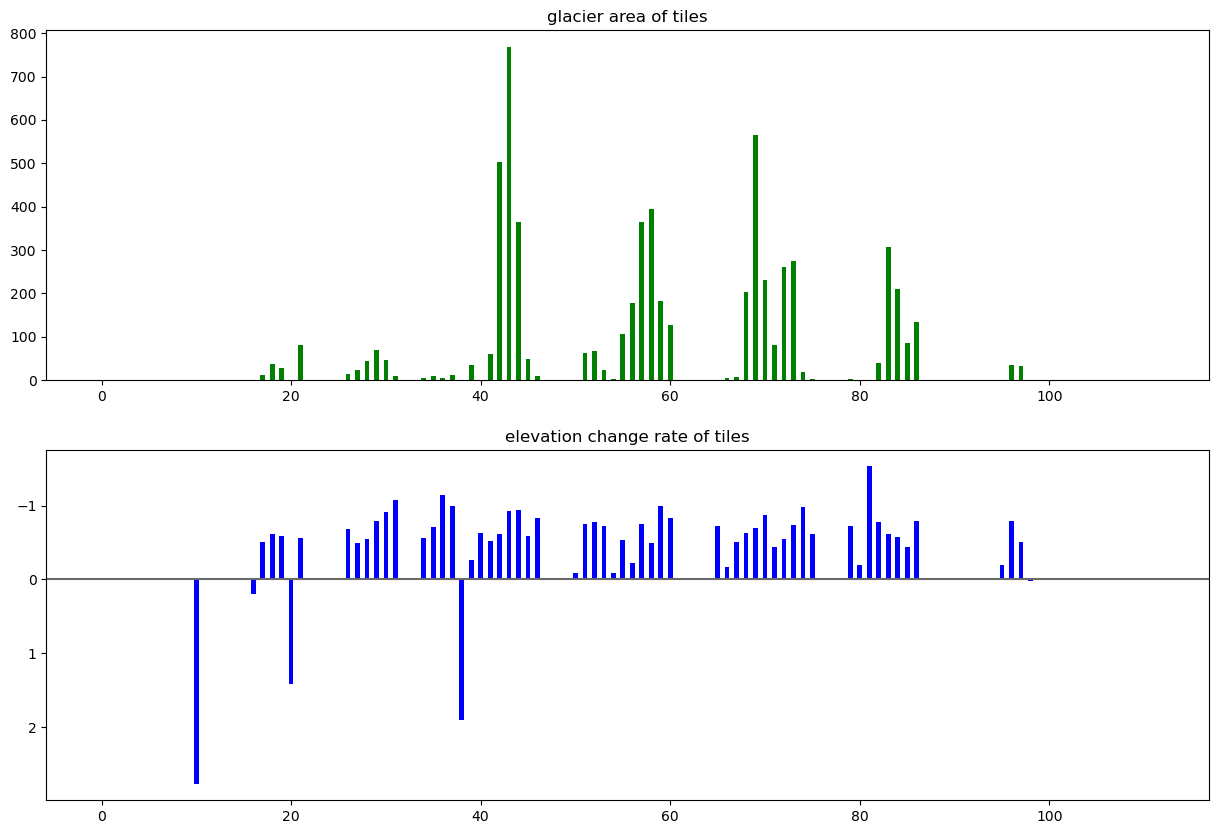

In [ ]:
## show glaicer area and elevation change rate of tiles.
plt.figure(figsize =(15, 10))
num_tiles = len(tiles_id)
width = 0.5
ax1 = plt.subplot(2,1,1)
ax1.bar(np.arange(num_tiles), stat_dif_dems_xr['area_glacier_tiles'].values, color='g', width=width)
plt.title('glacier area of tiles')

ax2 = plt.subplot(2,1,2, sharex=ax1)
ax2.axhline(y=0, color='dimgray', linestyle='-')
ax2.bar(np.arange(num_tiles), rate_tiles, color='b', width=width)
ax2.invert_yaxis()
plt.title('elevation change rate of tiles')


#### 2.3. Bin-based elevation changes.
##### !!! Note: the elevation change of bins is not corrected because the area of stable region of bins is largely unbalanced. 


In [60]:
### Calculate elevation change rate for each bin.
rate_bins = []
ele_change_bins_years = []
rate_error_bins = []
for bin_id in mean_bins_glacier_tilesWeighted.bins_id.values:
    ele_change_bin_years = mean_bins_glacier_tilesWeighted.sel(bins_id=bin_id).values
    ele_change_bin_years = np.where(ele_change_bin_years == 0, np.nan, ele_change_bin_years)
    mean_bin_glacier_filtered, mean_bin_glacier_fitting, rate_bin_glacier = \
                                                ransac_fitting(x=x_years, y=ele_change_bin_years, thre_mask=50)
    ## Uncertainty.
    if mean_bin_glacier_fitting is not np.nan:
      epsilon_bin =  ele_change_bin_years - mean_bin_glacier_fitting
      sigma_dh_bin = np.nanstd(epsilon_bin)
      sigma_dh_dt_bin = sigma_dh_bin/len(years)
      print(sigma_dh_dt_bin)
      rate_error_bins.append(sigma_dh_dt_bin)
    else: 
      rate_error_bins.append(np.nan)
    rate_bins.append(rate_bin_glacier)
    ele_change_bins_years.append(ele_change_bin_years)

area_glacier_bins = stat_dif_dems_xr['area_glacier_tiles_bins'].sum(dim='tiles_id').values
# ransac_coef_bins
ele_change_bins_years = np.stack(ele_change_bins_years, axis=0) 
ele_change_bins_years.shape


0.35929347370164877
1.6362914330404024
0.5263085268253188
0.749416160748151
0.2592706821227024
0.2660610647613778
0.3074543421081064
0.23346888554983405
0.17035367985071134
0.2528191267598793
0.25808747673277915
0.44289444585710613
0.16030698374287172
0.2355800796231918
0.202083512533674
0.18579978412236
0.186009563138553
0.1537379298143259
0.13311496972174025
0.14462799879121066
0.14127107326177527
0.1173482578965962
0.10801842240486625
0.08718772996184694
0.10226073374301806
0.10018830766756857
0.09029723576620728
0.087214820151807
0.0628903971421211
0.06856697357499635
0.07821821772095659
0.10157537536581972
0.09903605428568953
0.18602130301262293
0.15389042760274754
0.16098756968195166
0.23283424130508176
0.26723217055550674
0.30378274658517246
0.31671448081236264
0.46646895780406616
0.4086206965446082
0.3683924261040517
0.4101217863903726
0.31999376557926956
0.4720534999195171
0.7946777684334382


(50, 23)

Text(0.5, 1.0, 'selected tile')

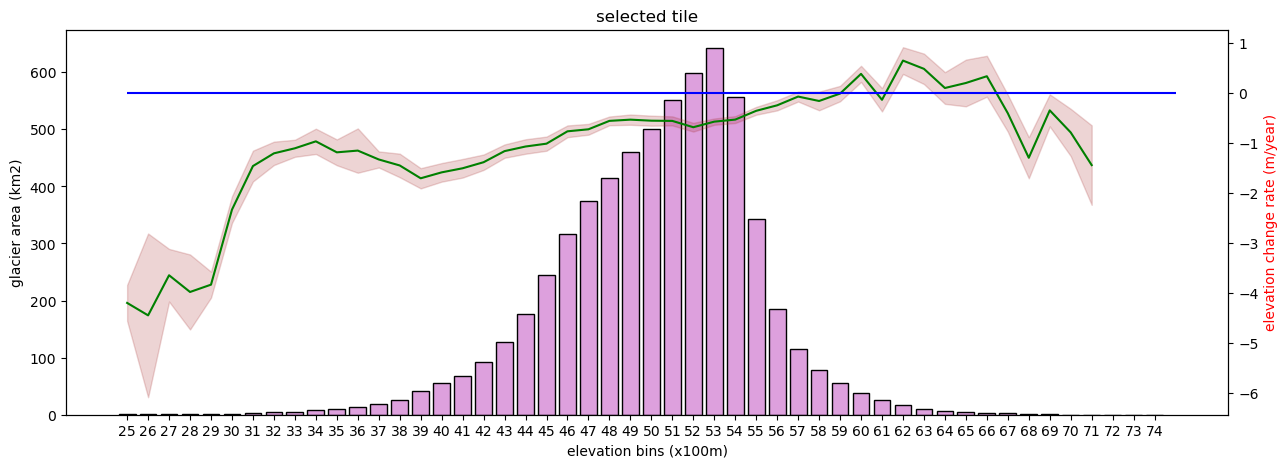

In [66]:
bins_id_start = [bin_id[0:2] for bin_id in bins_id]
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(111) # Create matplotlib axes
ax1.bar(bins_id_start, area_glacier_bins, color ='Plum', edgecolor ='black')
ax1.set_ylabel('glacier area (km2)')
ax1.set_xlabel('elevation bins (x100m)')
ax2 = ax1.twinx() # Create another axes that shares the same x-axis as ax.
ax2.set_ylabel('elevation change rate (m/year)', color='red')
ax2.plot(rate_bins, 'g')
ax2.fill_between(bins_id_start, np.array(rate_bins)-np.array(rate_error_bins), 
                 np.array(rate_bins)+np.array(rate_error_bins), color='Brown', alpha=0.2)

ax2.hlines(y=0, xmin=0, xmax=50, colors='blue')
# plt.xticks([1, 25, 50], [2500, 5000, 7500])
plt.xlabel('elevation (m)')
plt.title('selected tile')


#### **3. Write out the elevation change result.**


In [67]:
### 3) write out statistic of stable region to the xarray .nc file.
tiles_lat, tiles_lon = [], []
for tile_id in tiles_id:
    # print()
    tiles_lat.append(int(tile_id.split('_')[1]))
    tiles_lon.append(int(tile_id.split('_')[2]))


### Convert to xarray data.
result_dems_xr =xr.Dataset(
        {
        'tiles_lat': (["tiles_id"], tiles_lat),
        'tiles_lon': (["tiles_id"], tiles_lon),
        'area_glacier_bins': (["bins_id"], area_glacier_bins),
        'area_glacier_tiles': (["tiles_id"], stat_dif_dems_xr['area_glacier_tiles'].values),
        ### setp
        'ele_change_cor_setp': (["years"], mean_setp_glacier_cor),
        'ele_change_cor_error_setp': (["years"], std_setp_glacier_cor),           
        'ele_change_cor_fitting_setp': (["years"], mean_setp_glacier_cor_fitting),
        'rate_setp': rate_setp_glacier_cor,
        'rate_error_setp': sigma_dh_dt,
        ### tiles
        'ele_change_cor_tiles': (["tiles_id", "years"], mean_glacier_cor_tiles),
        'rate_tiles': (["tiles_id"], rate_tiles),
        'rate_error_tiles': (["tiles_id"], rate_error_tiles),
        ### bins
        'ele_change_cor_bins': (["bins_id", "years"], ele_change_bins_years),
        'rate_bins': (["bins_id"], rate_bins),
        'rate_error_bins': (["bins_id"], rate_error_bins),
        },
        coords={'tiles_id': tiles_id,
                'bins_id': bins_id,
                'years': years})

if os.path.exists(path_result_dems): os.remove(path_result_dems)
result_dems_xr.to_netcdf(path_result_dems)

